<a href="https://colab.research.google.com/github/galyalicia-art/AML-Final-Hinostroza-Galya/blob/main/Predicci%C3%B3n_de_tiempos_de_espera_en_emergencias_hospitalarias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn

# **Predicción de tiempos de espera en emergencias hospitalarias**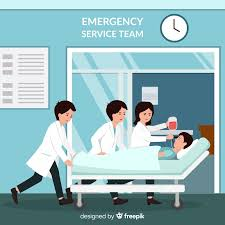

El pipeline incluye:

Generación / carga de datos

Limpieza de datos

Feature Engineering

Train/Test split

Pipeline con scikit-learn

Modelo XGBoost

Evaluación (MAE, RMSE)

Fairness por turno

Guardado del modelo

Simulación de predicciones

1. Instalación de librerías



In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn

2. Importar librerías

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

import joblib


3. dataset simulado del Hospital

hora de llegada

día

número de pacientes

médicos disponibles

enfermeras

nivel de triage

ocupación

tiempo de espera

In [4]:
np.random.seed(42)

n = 5000

data = pd.DataFrame({

    "hour": np.random.randint(0,24,n),

    "day_of_week": np.random.choice(
        ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], n),

    "patients_last_hour": np.random.poisson(10,n),

    "doctors_on_shift": np.random.randint(3,10,n),

    "nurses_on_shift": np.random.randint(5,15,n),

    "triage_level_avg": np.random.randint(1,5,n),

    "bed_occupancy": np.random.uniform(0.5,1.3,n)

})

# generar tiempo de espera

data["waiting_time"] = (
    5 * data["patients_last_hour"]
    - 3 * data["doctors_on_shift"]
    + 2 * data["triage_level_avg"]
    + 40 * data["bed_occupancy"]
    + np.random.normal(0,5,n)
)

data["waiting_time"] = data["waiting_time"].clip(5,180)

data.head()


,hour,day_of_week,patients_last_hour,doctors_on_shift,nurses_on_shift,triage_level_avg,bed_occupancy,waiting_time
0,6,Tue,5,3,9,3,0.813715,53.792723
1,19,Tue,10,5,10,1,0.526024,60.583184
2,14,Tue,9,7,6,3,0.787278,63.961109
3,10,Thu,13,4,13,3,1.178702,101.898235
4,7,Wed,3,6,10,4,0.807220,35.379005


4. Feature Engineering

  Creación de variables útiles para el modelo



In [5]:
def shift(hour):

    if hour < 8:
        return "night"

    elif hour < 16:
        return "morning"

    else:
        return "evening"

data["shift"] = data["hour"].apply(shift)

5. Separar variables

In [6]:
X = data.drop("waiting_time", axis=1)

y = data["waiting_time"]

6. Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)


7. Definir columnas

In [8]:
categorical_features = ["day_of_week","shift"]

numerical_features = [
    "hour",
    "patients_last_hour",
    "doctors_on_shift",
    "nurses_on_shift",
    "triage_level_avg",
    "bed_occupancy"
]


8. Preprocesamiento

In [9]:
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(

    transformers=[

        ("num", numeric_transformer, numerical_features),

        ("cat", categorical_transformer, categorical_features)

    ]

)


9. Modelo de Machine Learning

In [10]:
model = XGBRegressor(

    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42

)


10. Crear ML Pipeline

In [11]:
pipeline = Pipeline(

    steps=[

        ("preprocessing", preprocessor),

        ("model", model)

    ]

)


11. Entrenar el modelo

In [15]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['hour', 'patients_last_hour',
                                                   'doctors_on_shift',
                                                   'nurses_on_shift',
                                                   'triage_level_avg',
                                                   'bed_occupancy']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['day_of_week', 'shift'])])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=None,
                              num_parallel_tree=None, ...))])

12. Predicción

In [16]:
y_pred = pipeline.predict(X_test)


13. Evaluación del modelo

In [18]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)

print("RMSE:", rmse)


MAE: 4.23201876598281
RMSE: 5.294646673247803


14. Predicciones

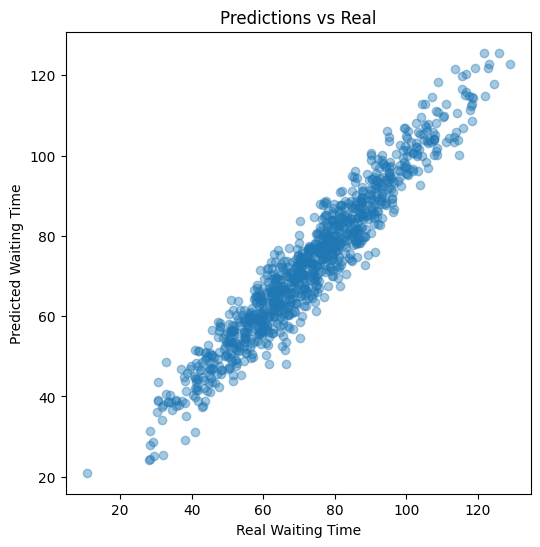

In [19]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.4)

plt.xlabel("Real Waiting Time")

plt.ylabel("Predicted Waiting Time")

plt.title("Predictions vs Real")

plt.show()


15. Fairness check por turno

In [20]:
test_data = X_test.copy()

test_data["real"] = y_test
test_data["pred"] = y_pred

shift_mae = test_data.groupby("shift").apply(
    lambda x: mean_absolute_error(x["real"], x["pred"])
)

print(shift_mae)


shift
evening    4.053938
morning    4.478332
night      4.168835
dtype: float64


/tmp/ipykernel_623/1987046951.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  shift_mae = test_data.groupby("shift").apply(


16. Guardar modelo

In [21]:
joblib.dump(pipeline, "hospital_waiting_time_model.pkl")


['hospital_waiting_time_model.pkl']

17. Simular predicción nueva

In [22]:
new_patient_flow = pd.DataFrame({

    "hour":[19],
    "day_of_week":["Fri"],
    "patients_last_hour":[15],
    "doctors_on_shift":[5],
    "nurses_on_shift":[10],
    "triage_level_avg":[3],
    "bed_occupancy":[1.1],
    "shift":["evening"]

})

prediction = pipeline.predict(new_patient_flow)

print("Predicted waiting time:", prediction[0], "minutes")


Predicted waiting time: 109.10355 minutes
